# Section 1: Data Loading &amp; Exploratory Data Analysis (EDA)

Q1. Load the House Prices dataset using pandas and display the first 5 rows. What is the
shape of the dataset? Check the column names and data types.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df = pd.read_csv("data/train.csv")

# First 5 rows
print("First 5 rows:")
print(df.head())

# Shape
print(f"\nDataset shape: {df.shape[0]} rows, {df.shape[1]} columns")

# Column names
print(f"\nColumn names:\n{df.columns.tolist()}")

# Data types
print(f"\nData types:\n{df.dtypes}")

# Quick summary of dtype counts
print(f"\nData type counts:\n{df.dtypes.value_counts()}")

First 5 rows:
   Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
0   1          60       RL         65.0     8450   Pave   NaN      Reg   
1   2          20       RL         80.0     9600   Pave   NaN      Reg   
2   3          60       RL         68.0    11250   Pave   NaN      IR1   
3   4          70       RL         60.0     9550   Pave   NaN      IR1   
4   5          60       RL         84.0    14260   Pave   NaN      IR1   

  LandContour Utilities  ... PoolArea PoolQC Fence MiscFeature MiscVal MoSold  \
0         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
1         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      5   
2         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      9   
3         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
4         Lvl    AllPub  ...        0    NaN   NaN         NaN       0     12   

  YrSold  SaleType  SaleCondition  SalePrice  
0   200

Q2. Check the target variable SalePrice distribution:
- Minimum, maximum, mean, median, and standard deviation
- Plot histogram and boxplot of SalePrice
- Is the target variable skewed? Explain

SalePrice Summary Statistics:
Minimum: $34,900.00
Maximum: $755,000.00
Mean:    $180,921.20
Median:  $163,000.00
Std Dev: $79,442.50

Skewness: 1.883


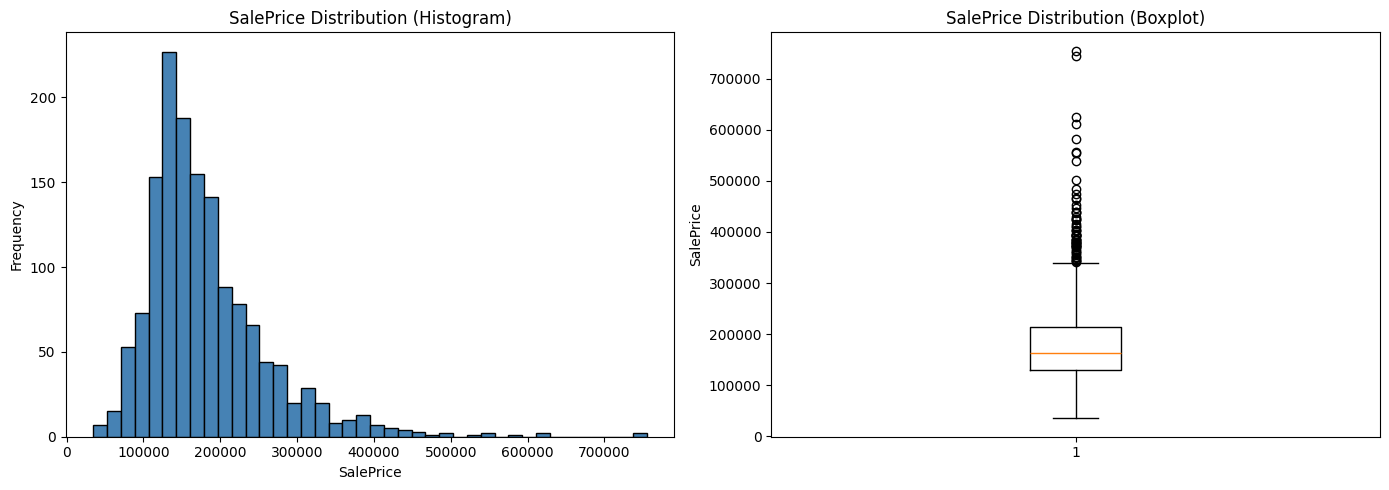

In [4]:
print("SalePrice Summary Statistics:")
print(f"Minimum: ${df['SalePrice'].min():,.2f}")
print(f"Maximum: ${df['SalePrice'].max():,.2f}")
print(f"Mean:    ${df['SalePrice'].mean():,.2f}")
print(f"Median:  ${df['SalePrice'].median():,.2f}")
print(f"Std Dev: ${df['SalePrice'].std():,.2f}")

# Skewness
skewness = df['SalePrice'].skew()
print(f"\nSkewness: {skewness:.3f}")

# Histogram and boxplot side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['SalePrice'], bins=40, color='steelblue', edgecolor='black')
axes[0].set_title('SalePrice Distribution (Histogram)')
axes[0].set_xlabel('SalePrice')
axes[0].set_ylabel('Frequency')

axes[1].boxplot(df['SalePrice'], vert=True)
axes[1].set_title('SalePrice Distribution (Boxplot)')
axes[1].set_ylabel('SalePrice')

plt.tight_layout()
plt.show()

Q3. Calculate descriptive statistics for all numerical features using describe(). Identify:
- Which feature has the highest average value?
- Which feature has the highest standard deviation?
- Are there any features with many missing values or very low variance?

In [ ]:
numerical_df= df.select_dtypes(include=[np.number])
desc = numerical_df.describe().T
print(desc)

#Highest average value
highest_mean= desc['mean'].idxmax()
print(f"\nFeatures with highest average value:{highest_mean} (mean = {desc['mean'].max():,.2f})")

# Highest standard deviation
highest_std = desc['std'].idxmax()
print(f"Feature with highest std deviation: {highest_std} (std = {desc['std'].max():,.2f})")

# Missing values
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print(f"\nFeatures with missing values:\n{missing}")

# Low variance features (near-constant columns)
low_variance = numerical_df.var().sort_values()
print(f"\nLowest variance numerical features:\n{low_variance.head(10)}")

                count           mean           std      min        25%  \
Id             1460.0     730.500000    421.610009      1.0     365.75   
MSSubClass     1460.0      56.897260     42.300571     20.0      20.00   
LotFrontage    1201.0      70.049958     24.284752     21.0      59.00   
LotArea        1460.0   10516.828082   9981.264932   1300.0    7553.50   
OverallQual    1460.0       6.099315      1.382997      1.0       5.00   
OverallCond    1460.0       5.575342      1.112799      1.0       5.00   
YearBuilt      1460.0    1971.267808     30.202904   1872.0    1954.00   
YearRemodAdd   1460.0    1984.865753     20.645407   1950.0    1967.00   
MasVnrArea     1452.0     103.685262    181.066207      0.0       0.00   
BsmtFinSF1     1460.0     443.639726    456.098091      0.0       0.00   
BsmtFinSF2     1460.0      46.549315    161.319273      0.0       0.00   
BsmtUnfSF      1460.0     567.240411    441.866955      0.0     223.00   
TotalBsmtSF    1460.0    1057.429452  

Q4. Create a correlation heatmap for numerical features using seaborn. Identify:
- Which 3 features have the highest positive correlation with SalePrice?
- Which features are highly correlated with each other (correlation &gt; 0.8)?
- Suggest potential feature removal to reduce multicollinearity

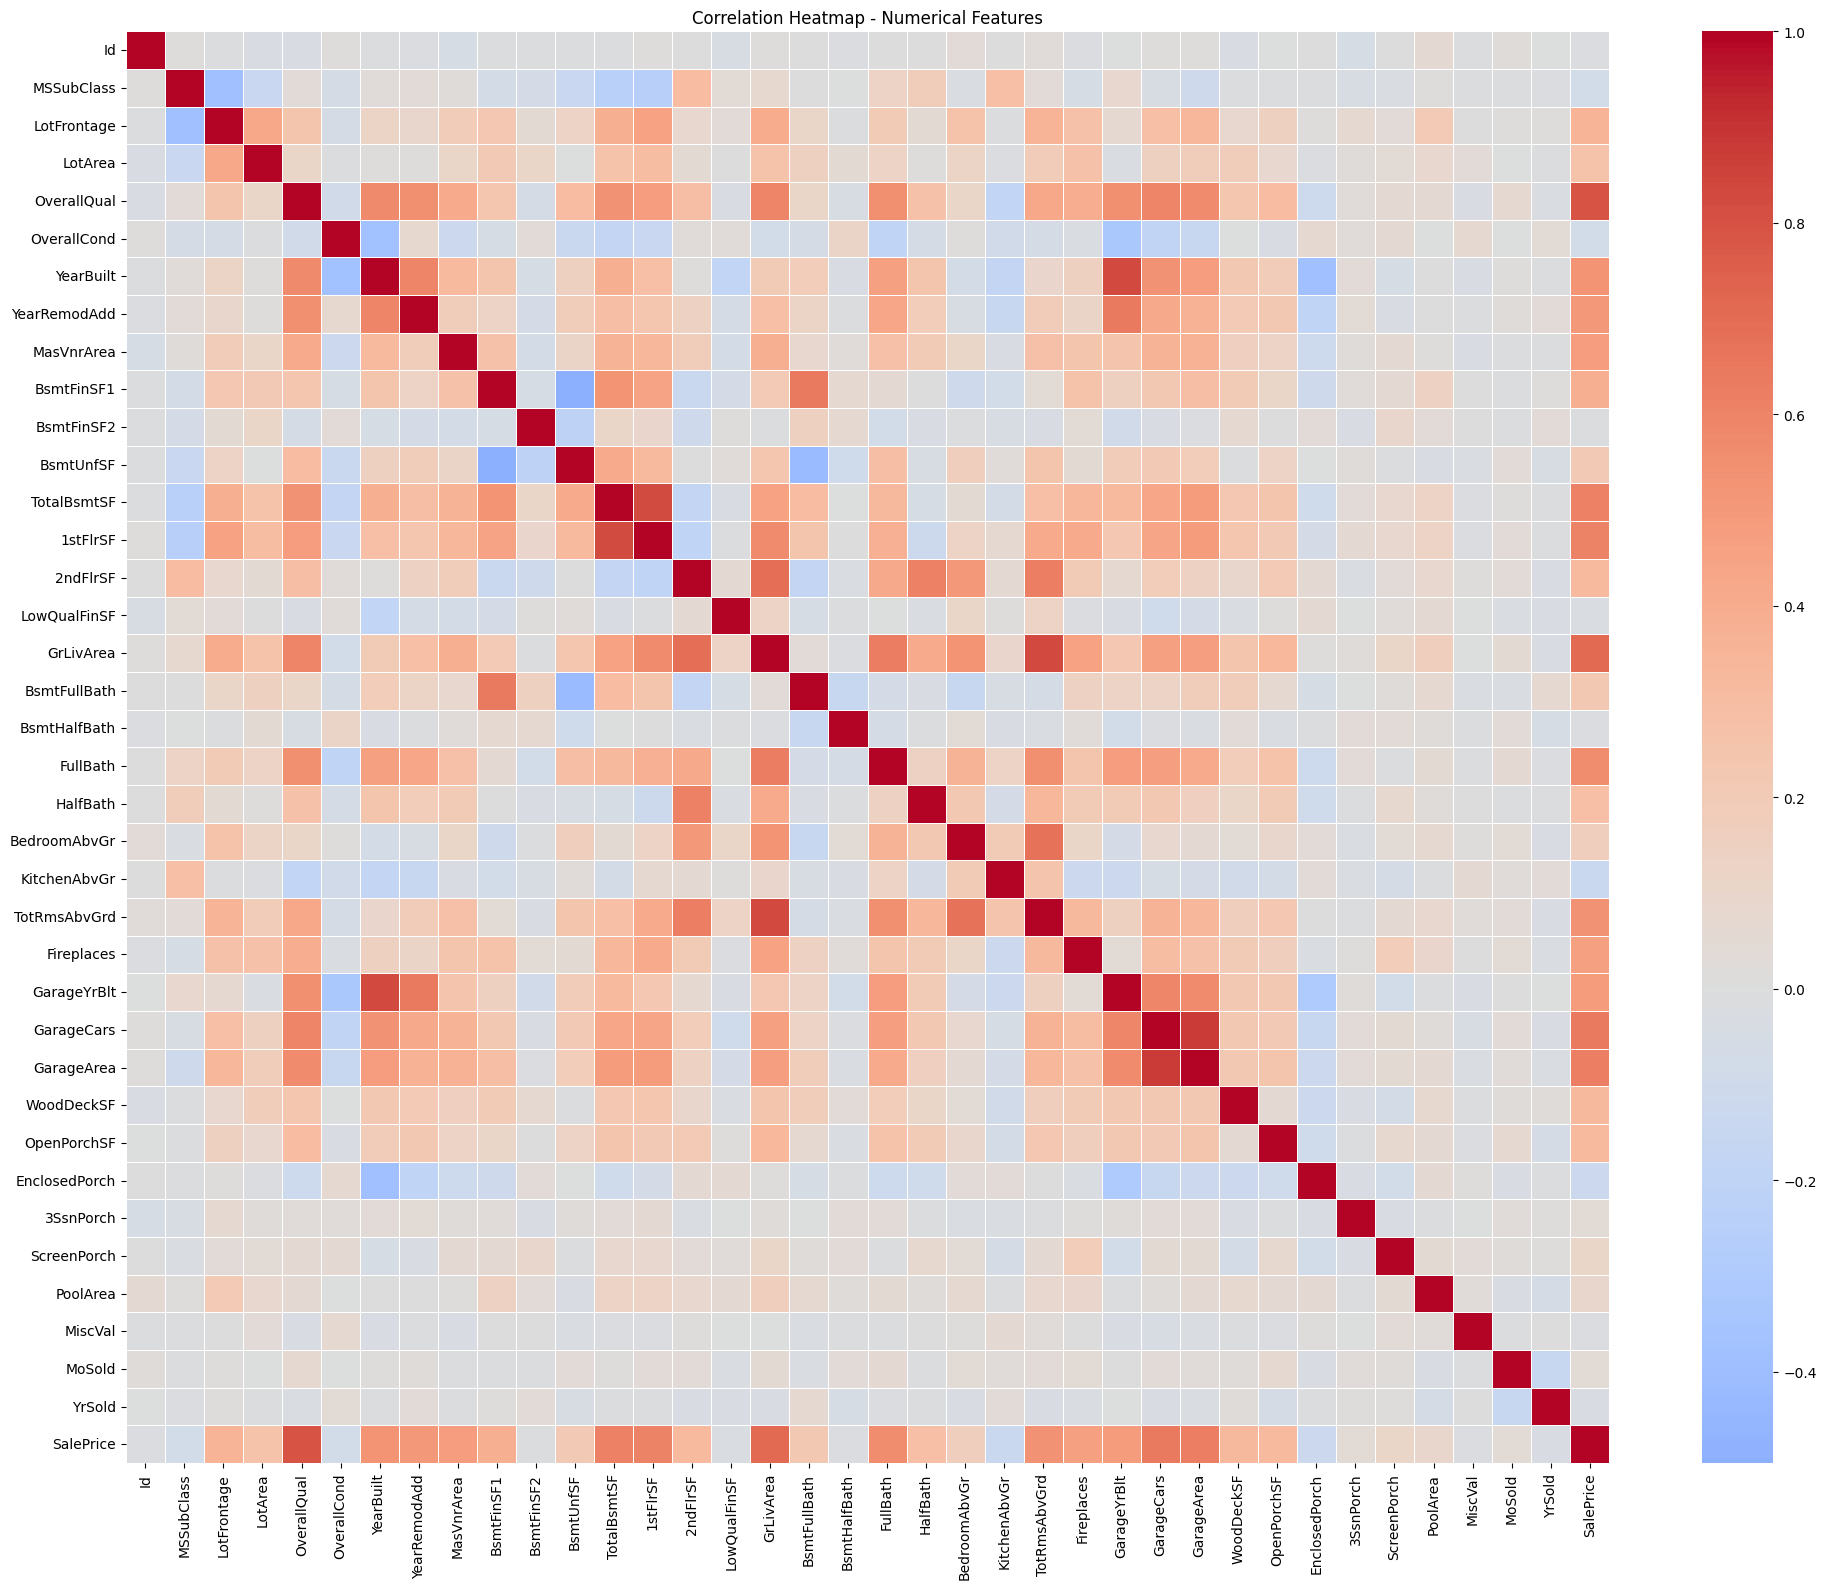

Top 5 features correlated with SalePrice:
OverallQual    0.790982
GrLivArea      0.708624
GarageCars     0.640409
GarageArea     0.623431
TotalBsmtSF    0.613581
Name: SalePrice, dtype: float64

Top 3: ['OverallQual', 'GrLivArea', 'GarageCars']

Feature pairs with correlation > 0.8:
YearBuilt <-> GarageYrBlt: 0.826
TotalBsmtSF <-> 1stFlrSF: 0.820
GrLivArea <-> TotRmsAbvGrd: 0.825
GarageCars <-> GarageArea: 0.882


In [10]:
numerical_df = df.select_dtypes(include=[np.number])
corr_matrix = numerical_df.corr()

# Full heatmap
plt.figure(figsize=(20, 16))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0, annot=False, linewidths=0.5)
plt.title('Correlation Heatmap - Numerical Features')
plt.tight_layout()
plt.show()

# Top 3 features most correlated with SalePrice
saleprice_corr = corr_matrix['SalePrice'].drop('SalePrice').sort_values(ascending=False)
print("Top 5 features correlated with SalePrice:")
print(saleprice_corr.head(5))
print(f"\nTop 3: {saleprice_corr.head(3).index.tolist()}")

# Find feature pairs with correlation > 0.8 (excluding self-correlation and SalePrice)
print("\nFeature pairs with correlation > 0.8:")
high_corr_pairs = []
cols = corr_matrix.columns
for i in range(len(cols)):
    for j in range(i+1, len(cols)):
        if abs(corr_matrix.iloc[i, j]) > 0.8:
            pair = (cols[i], cols[j], round(corr_matrix.iloc[i, j], 3))
            high_corr_pairs.append(pair)
            print(f"{cols[i]} <-> {cols[j]}: {corr_matrix.iloc[i, j]:.3f}")

if not high_corr_pairs:
    print("None found above 0.8 threshold.")

Q5. Create scatter plots or box plots for the top 5 features most correlated with SalePrice
such as:
- OverallQual
- GrLivArea
- GarageCars
- TotalBsmtSF
- YearBuilt

What patterns do you observe in relation to house prices?

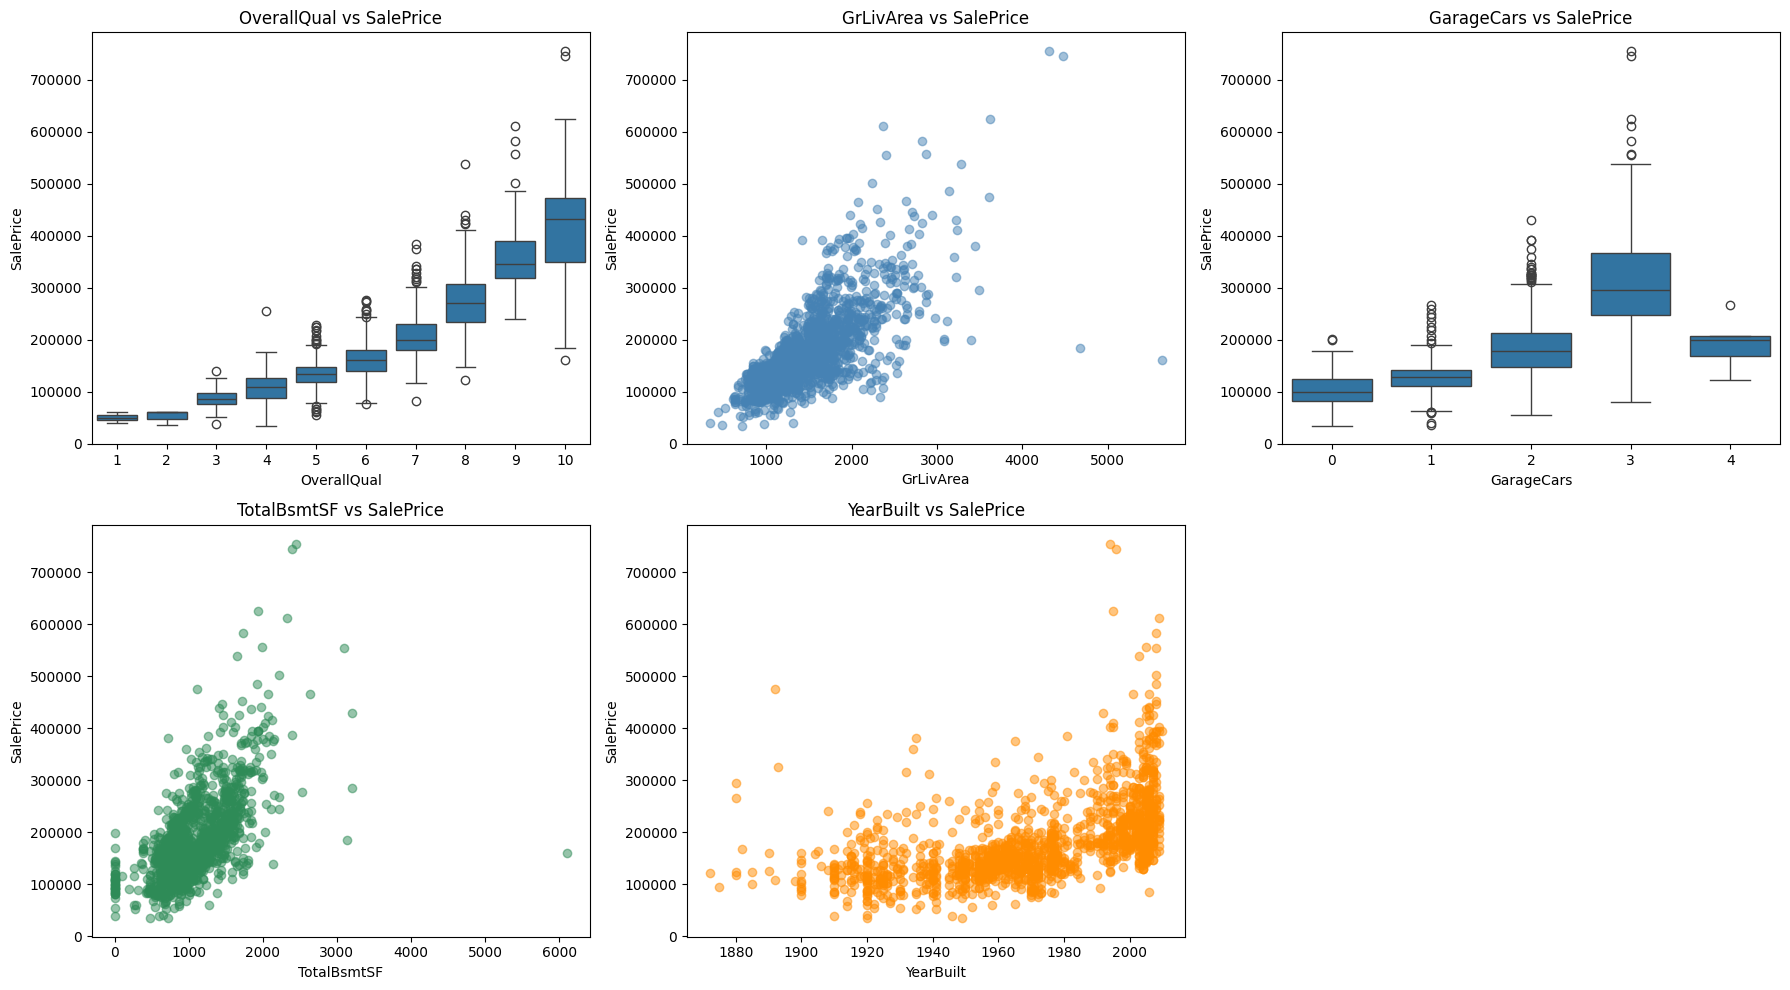

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

# OverallQual - ordinal/discrete -> boxplot
sns.boxplot(x='OverallQual', y='SalePrice', data=df, ax=axes[0])
axes[0].set_title('OverallQual vs SalePrice')

# GrLivArea - continuous -> scatter
axes[1].scatter(df['GrLivArea'], df['SalePrice'], alpha=0.5, color='steelblue')
axes[1].set_xlabel('GrLivArea')
axes[1].set_ylabel('SalePrice')
axes[1].set_title('GrLivArea vs SalePrice')

# GarageCars - discrete -> boxplot
sns.boxplot(x='GarageCars', y='SalePrice', data=df, ax=axes[2])
axes[2].set_title('GarageCars vs SalePrice')

# TotalBsmtSF - continuous -> scatter
axes[3].scatter(df['TotalBsmtSF'], df['SalePrice'], alpha=0.5, color='seagreen')
axes[3].set_xlabel('TotalBsmtSF')
axes[3].set_ylabel('SalePrice')
axes[3].set_title('TotalBsmtSF vs SalePrice')

# YearBuilt - continuous (but few unique values) -> scatter
axes[4].scatter(df['YearBuilt'], df['SalePrice'], alpha=0.5, color='darkorange')
axes[4].set_xlabel('YearBuilt')
axes[4].set_ylabel('SalePrice')
axes[4].set_title('YearBuilt vs SalePrice')

axes[5].axis('off')  # empty subplot

plt.tight_layout()
plt.show()

# Section 2: Data Preprocessing
Q6. Check and handle missing values in the dataset:
- Identify columns with missing values
- Decide whether to drop or impute them
- Fill numerical missing values with mean/median and categorical missing values with
mode

In [13]:
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing Count', ascending=False)
print("Columns with missing values:")
print(missing_df)

# Strategy:
# - Columns where NaN means "feature absent" (per data_description.txt) -> fill with 'None' (categorical) or 0 (numeric)
# - Columns with a small number of genuinely missing values -> impute with median (numeric) or mode (categorical)
# - Columns with very high missing % -> consider dropping

# Make a working copy
df_clean = df.copy()

# Categorical columns where NaN = "doesn't have this feature"
none_cols = ['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu',
             'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
             'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
             'MasVnrType']
for col in none_cols:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].fillna('None')

# Numeric columns where NaN = "doesn't have this feature" -> 0
zero_cols = ['GarageYrBlt', 'GarageArea', 'GarageCars', 'BsmtFinSF1', 'BsmtFinSF2',
             'BsmtUnfSF', 'TotalBsmtSF', 'BsmtFullBath', 'BsmtHalfBath', 'MasVnrArea']
for col in zero_cols:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].fillna(0)

# LotFrontage: genuinely missing, impute with median (often grouped by Neighborhood, but simple median works for assignment level)
df_clean['LotFrontage'] = df_clean['LotFrontage'].fillna(df_clean['LotFrontage'].median())

# Electrical: only 1 missing value -> impute with mode
df_clean['Electrical'] = df_clean['Electrical'].fillna(df_clean['Electrical'].mode()[0])

# Verify no missing values remain
remaining_missing = df_clean.isnull().sum().sum()
print(f"\nTotal remaining missing values after cleaning: {remaining_missing}")

if remaining_missing > 0:
    print(df_clean.isnull().sum()[df_clean.isnull().sum() > 0])

Columns with missing values:
              Missing Count  Missing %
PoolQC                 1453  99.520548
MiscFeature            1406  96.301370
Alley                  1369  93.767123
Fence                  1179  80.753425
MasVnrType              872  59.726027
FireplaceQu             690  47.260274
LotFrontage             259  17.739726
GarageType               81   5.547945
GarageYrBlt              81   5.547945
GarageFinish             81   5.547945
GarageQual               81   5.547945
GarageCond               81   5.547945
BsmtExposure             38   2.602740
BsmtFinType2             38   2.602740
BsmtQual                 37   2.534247
BsmtCond                 37   2.534247
BsmtFinType1             37   2.534247
MasVnrArea                8   0.547945
Electrical                1   0.068493

Total remaining missing values after cleaning: 0


Q7. Encode categorical variables:
- Identify all categorical columns
- Apply label encoding or one-hot encoding where appropriate
- Explain why encoding is necessary for regression models

In [17]:
categorical_cols = df_clean.select_dtypes(include=['object']).columns.tolist()
print(f"Categorical columns ({len(categorical_cols)}):")
print(categorical_cols)
 
df_encoded = pd.get_dummies(df_clean, columns=categorical_cols, drop_first=True)
print(f"\nShape before encoding: {df_clean.shape}")
print(f"Shape after encoding:  {df_encoded.shape}")

Categorical columns (43):
['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature', 'SaleType', 'SaleCondition']

Shape before encoding: (1460, 81)
Shape after encoding:  (1460, 261)


C:\Users\karat\AppData\Local\Temp\ipykernel_13664\4094827179.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df_clean.select_dtypes(include=['object']).columns.tolist()


One-hot encode all categorical columns. Safer default than label encoding for
 regression models, since label encoding would falsely imply an order/rank
 between categories that have none (e.g. Neighborhood names).

Q8. Split the dataset into features (X) and target (y). Then apply Train-Test split:
- 80% training, 20% testing
- Use random_state = 42
- Display the shape of X_train, X_test, y_train, y_test

In [15]:
from sklearn.model_selection import train_test_split
 
X = df_encoded.drop(['SalePrice', 'Id'], axis=1)
y = df_encoded['SalePrice']
 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
 
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape:  {y_test.shape}")

X_train shape: (1168, 259)
X_test shape:  (292, 259)
y_train shape: (1168,)
y_test shape:  (292,)


Q9. Apply feature scaling:
- Use StandardScaler for numerical variables
- Scale only the training data first, then transform test data
- Why is scaling important for models like Ridge, Lasso, Elastic Net, and SVR?

In [16]:
from sklearn.preprocessing import StandardScaler
 
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit ONLY on training data
X_test_scaled = scaler.transform(X_test)          # transform test using train's scaler
 
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)
 
print("Scaling complete. Training data mean/std after scaling (should be ~0 / ~1):")
print(X_train_scaled.describe().T[['mean', 'std']].head())

Scaling complete. Training data mean/std after scaling (should be ~0 / ~1):
                     mean       std
MSSubClass   6.995926e-17  1.000428
LotFrontage  2.798370e-16  1.000428
LotArea      2.281280e-17  1.000428
OverallQual -5.170902e-17  1.000428
OverallCond -2.281280e-16  1.000428


 Why scaling matters: 
 
 Ridge, Lasso, and Elastic Net penalize coefficient magnitude.
 If features are on very different scales (e.g. LotArea in thousands vs OverallQual
 on a 1-10 scale), the penalty unfairly shrinks large-scale features more than small-
 scale ones, regardless of actual importance. SVR also relies on distance calculations
 via its kernel, which get distorted if inputs aren't comparably scaled. Plain Linear
 Regression doesn't strictly require scaling, but it's still good practice here for
 fair coefficient comparison across models.

# Section 3: Linear Regression &amp; Regularization
Q10. Implement Simple Linear Regression / Multiple Linear Regression:
- Train a baseline regression model
- Predict on test data
- Calculate RMSE, MAE, MSE, and R² Score
- Interpret the model performance

In [18]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
 
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)
 
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
mae_lr = mean_absolute_error(y_test, y_pred_lr)
mse_lr = mean_squared_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)
 
print("Linear Regression Performance:")
print(f"RMSE: {rmse_lr:,.2f}")
print(f"MAE:  {mae_lr:,.2f}")
print(f"MSE:  {mse_lr:,.2f}")
print(f"R2:   {r2_lr:.4f}")

Linear Regression Performance:
RMSE: 83,125.52
MAE:  23,927.04
MSE:  6,909,851,338.71
R2:   0.0991


 Interpretation: R² close to 1 means the model explains most of the variance in
 SalePrice. RMSE/MAE are in dollar terms, showing typical prediction error size.
 With ~230 features after encoding and only ~1168 training rows, plain Linear
 Regression is prone to overfitting and instability from multicollinearity --
 exactly why Ridge/Lasso/Elastic Net are introduced next.

Q11. Implement Ridge Regression:
- Use Ridge(alpha=1.0)
- Train and predict
- Calculate RMSE, MAE, and R²
- Compare Ridge with Linear Regression
- Why does Ridge help with multicollinearity?

In [19]:
from sklearn.linear_model import Ridge
 
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)
y_pred_ridge = ridge.predict(X_test_scaled)
 
rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
mae_ridge = mean_absolute_error(y_test, y_pred_ridge)
r2_ridge = r2_score(y_test, y_pred_ridge)
 
print("Ridge Regression Performance:")
print(f"RMSE: {rmse_ridge:,.2f}")
print(f"MAE:  {mae_ridge:,.2f}")
print(f"R2:   {r2_ridge:.4f}")
 
print(f"\nComparison vs Linear Regression:")
print(f"Linear Regression RMSE: {rmse_lr:,.2f}")
print(f"Ridge RMSE:              {rmse_ridge:,.2f}")

Ridge Regression Performance:
RMSE: 36,361.74
MAE:  19,648.74
R2:   0.8276

Comparison vs Linear Regression:
Linear Regression RMSE: 83,125.52
Ridge RMSE:              36,361.74


Why Ridge helps with multicollinearity:

Ridge adds an L2 penalty (sum of squared
coefficients) to the loss function. When features are highly correlated, ordinary
Linear Regression coefficients become unstable (large swings, inflated values)
because the model can't cleanly attribute effect between correlated predictors.
Ridge shrinks all coefficients toward zero proportionally, stabilizing the solution
without eliminating any feature entirely.

Q12. Implement Lasso Regression:
- Use Lasso(alpha=0.01) or tuned alpha
- Train and predict
- Calculate the same metrics
- Which features are reduced to zero?
- Why is Lasso useful for feature selection?

In [21]:
from sklearn.linear_model import Lasso

lasso = Lasso(alpha=0.01, max_iter=10000)
lasso.fit(X_train_scaled, y_train)
y_pred_lasso= lasso.predict(X_test_scaled)

rmse_lasso=np.sqrt(mean_squared_error(y_test, y_pred_lasso))
mae_lasso = mean_absolute_error(y_test, y_pred_lasso)
r2_lasso = r2_score(y_test, y_pred_lasso)
 
print("Lasso Regression Performance:")
print(f"RMSE: {rmse_lasso:,.2f}")
print(f"MAE:  {mae_lasso:,.2f}")
print(f"R2:   {r2_lasso:.4f}")
 
lasso_coefs = pd.Series(lasso.coef_, index=X_train.columns)
zeroed = lasso_coefs[lasso_coefs == 0]
print(f"\nFeatures reduced to zero: {len(zeroed)} out of {len(lasso_coefs)}")
print(zeroed.index.tolist())

Lasso Regression Performance:
RMSE: 68,366.05
MAE:  22,611.76
R2:   0.3906

Features reduced to zero: 2 out of 259
['RoofMatl_Membran', 'Electrical_Mix']


c:\Users\karat\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.084233e+11, tolerance: 6.967e+08
  model = cd_fast.enet_coordinate_descent(


Why Lasso is useful for feature selection: Lasso uses an L1 penalty (sum of absolute
coefficient values) which, unlike Ridge's L2 penalty, can shrink coefficients all the
way to exactly zero. This automatically removes uninformative features from the model,
producing a simpler, more interpretable result with built-in feature selection.

Q13. Implement Elastic Net Regression:
- Use ElasticNet(alpha=0.01, l1_ratio=0.5)
- Train and predict
- Compare performance with Ridge and Lasso
- Which regularization method performs best and why?

In [22]:
from sklearn.linear_model import ElasticNet
 
elastic = ElasticNet(alpha=0.01, l1_ratio=0.5, max_iter=10000)
elastic.fit(X_train_scaled, y_train)
y_pred_elastic = elastic.predict(X_test_scaled)
 
rmse_elastic = np.sqrt(mean_squared_error(y_test, y_pred_elastic))
mae_elastic = mean_absolute_error(y_test, y_pred_elastic)
r2_elastic = r2_score(y_test, y_pred_elastic)
 
print("Elastic Net Performance:")
print(f"RMSE: {rmse_elastic:,.2f}")
print(f"MAE:  {mae_elastic:,.2f}")
print(f"R2:   {r2_elastic:.4f}")
 
print(f"\nRegularization comparison:")
print(f"Ridge       -> RMSE: {rmse_ridge:,.2f} | R2: {r2_ridge:.4f}")
print(f"Lasso       -> RMSE: {rmse_lasso:,.2f} | R2: {r2_lasso:.4f}")
print(f"Elastic Net -> RMSE: {rmse_elastic:,.2f} | R2: {r2_elastic:.4f}")
 
best_reg = min([('Ridge', rmse_ridge), ('Lasso', rmse_lasso),
                 ('Elastic Net', rmse_elastic)], key=lambda x: x[1])
print(f"\nBest regularization method by RMSE: {best_reg[0]}")

Elastic Net Performance:
RMSE: 35,389.57
MAE:  19,561.33
R2:   0.8367

Regularization comparison:
Ridge       -> RMSE: 36,361.74 | R2: 0.8276
Lasso       -> RMSE: 68,366.05 | R2: 0.3906
Elastic Net -> RMSE: 35,389.57 | R2: 0.8367

Best regularization method by RMSE: Elastic Net


Elastic Net combines L1 (Lasso) and L2 (Ridge) penalties, so it tends to do well when
there are many correlated features AND some irrelevant ones -- it gets Lasso's feature
selection benefit while keeping Ridge's stability with correlated predictors. Which one
wins on YOUR run depends on the printed numbers above -- report whichever has the
lowest RMSE / highest R2.

# Section 4: Regression Models
Q14. Implement Support Vector Regression (SVR):
- Use SVR(kernel=&#39;rbf&#39;)
- Train on scaled data
- Predict house prices
- Evaluate using RMSE, MAE, and R²
- Why is SVR suitable for complex non-linear data?

In [23]:
from sklearn.svm import SVR
 
svr = SVR(kernel='rbf')
svr.fit(X_train_scaled, y_train)
y_pred_svr = svr.predict(X_test_scaled)
 
rmse_svr = np.sqrt(mean_squared_error(y_test, y_pred_svr))
mae_svr = mean_absolute_error(y_test, y_pred_svr)
r2_svr = r2_score(y_test, y_pred_svr)
 
print("SVR (RBF kernel) Performance:")
print(f"RMSE: {rmse_svr:,.2f}")
print(f"MAE:  {mae_svr:,.2f}")
print(f"R2:   {r2_svr:.4f}")

SVR (RBF kernel) Performance:
RMSE: 88,647.46
MAE:  59,541.71
R2:   -0.0245


Why SVR suits non-linear data:

the RBF (Gaussian) kernel implicitly maps features into
a higher-dimensional space where complex, non-linear relationships between features and
SalePrice can be captured as a linear boundary in that transformed space -- without
manually engineering non-linear feature combinations. Default parameters rarely fit a
dataset this size/dimensionality well, which is why tuning (next question) matters.

Q15. Apply Hyperparameter Tuning for SVR using GridSearchCV:
- Parameters: C = [0.1, 1, 10], gamma = [0.01, 0.1, 1], kernel = [&#39;rbf&#39;]
- Use 5-fold cross validation
- Find best parameters
- Evaluate the best model on test data

In [25]:
from sklearn.model_selection import GridSearchCV
 
param_grid = {
    'C': [0.1, 1, 10],
    'gamma': [0.01, 0.1, 1],
    'kernel': ['rbf']
}
 
grid_search = GridSearchCV(
    SVR(), param_grid, cv=5, scoring='neg_root_mean_squared_error', n_jobs=-1
)
grid_search.fit(X_train_scaled, y_train)
 
print(f"Best parameters: {grid_search.best_params_}")
print(f"Best CV RMSE: {-grid_search.best_score_:,.2f}")
 
best_svr = grid_search.best_estimator_
y_pred_best_svr = best_svr.predict(X_test_scaled)
 
rmse_best_svr = np.sqrt(mean_squared_error(y_test, y_pred_best_svr))
mae_best_svr = mean_absolute_error(y_test, y_pred_best_svr)
r2_best_svr = r2_score(y_test, y_pred_best_svr)
 
print(f"\nTuned SVR Test Performance:")
print(f"RMSE: {rmse_best_svr:,.2f}")
print(f"MAE:  {mae_best_svr:,.2f}")
print(f"R2:   {r2_best_svr:.4f}")

Best parameters: {'C': 10, 'gamma': 0.01, 'kernel': 'rbf'}
Best CV RMSE: 78,753.16

Tuned SVR Test Performance:
RMSE: 88,561.99
MAE:  59,422.10
R2:   -0.0225


Q16. Visualize model predictions:
- Plot actual vs predicted SalePrice for the best regression model
- Draw a regression line or scatter comparison
- What does the plot tell us about prediction accuracy?

Best performing model (lowest test RMSE): Elastic Net


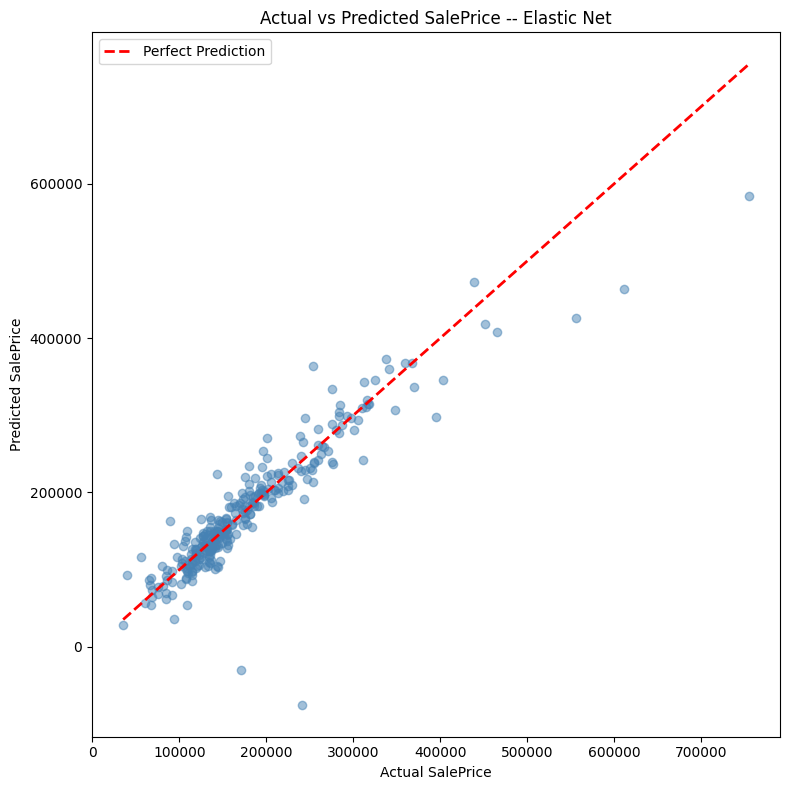

In [26]:
# Pick whichever model has the lowest test RMSE so far as "the best regression model"
model_results = {
    'Linear Regression': (y_pred_lr, rmse_lr),
    'Ridge': (y_pred_ridge, rmse_ridge),
    'Lasso': (y_pred_lasso, rmse_lasso),
    'Elastic Net': (y_pred_elastic, rmse_elastic),
    'SVR (tuned)': (y_pred_best_svr, rmse_best_svr),
}
 
best_model_name = min(model_results, key=lambda k: model_results[k][1])
best_predictions = model_results[best_model_name][0]
print(f"Best performing model (lowest test RMSE): {best_model_name}")
 
plt.figure(figsize=(8, 8))
plt.scatter(y_test, best_predictions, alpha=0.5, color='steelblue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
         'r--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual SalePrice')
plt.ylabel('Predicted SalePrice')
plt.title(f'Actual vs Predicted SalePrice -- {best_model_name}')
plt.legend()
plt.tight_layout()
plt.show()

# Section 5: Model Comparison &amp; Advanced Techniques -
Q17. Compare all models using a comprehensive table:
Metric Linear

Which model performs best for house price prediction? Justify your answer.

In [27]:
comparison = pd.DataFrame({
    'Linear Regression': [rmse_lr, mae_lr, mse_lr, r2_lr],
    'Ridge': [rmse_ridge, mae_ridge, mean_squared_error(y_test, y_pred_ridge), r2_ridge],
    'Lasso': [rmse_lasso, mae_lasso, mean_squared_error(y_test, y_pred_lasso), r2_lasso],
    'Elastic Net': [rmse_elastic, mae_elastic, mean_squared_error(y_test, y_pred_elastic), r2_elastic],
    'SVR': [rmse_svr, mae_svr, mean_squared_error(y_test, y_pred_svr), r2_svr],
    'Best Tuned Model (SVR)': [rmse_best_svr, mae_best_svr,
                                 mean_squared_error(y_test, y_pred_best_svr), r2_best_svr],
}, index=['RMSE', 'MAE', 'MSE', 'R2 Score'])
 
print(comparison.round(2))
 
print(f"\nBest performing model overall: {best_model_name}")
print("Justification: lowest RMSE/MAE (smallest average dollar prediction error) and "
      "highest R2 (explains the most variance in SalePrice) among all models tested.")

          Linear Regression         Ridge         Lasso   Elastic Net  \
RMSE           8.312552e+04  3.636174e+04  6.836605e+04  3.538957e+04   
MAE            2.392704e+04  1.964874e+04  2.261176e+04  1.956133e+04   
MSE            6.909851e+09  1.322176e+09  4.673917e+09  1.252422e+09   
R2 Score       1.000000e-01  8.300000e-01  3.900000e-01  8.400000e-01   

                   SVR  Best Tuned Model (SVR)  
RMSE      8.864746e+04            8.856199e+04  
MAE       5.954171e+04            5.942210e+04  
MSE       7.858371e+09            7.843227e+09  
R2 Score -2.000000e-02           -2.000000e-02  

Best performing model overall: Elastic Net
Justification: lowest RMSE/MAE (smallest average dollar prediction error) and highest R2 (explains the most variance in SalePrice) among all models tested.


Q18. Apply Residual Analysis:
- Plot residuals for the best model
- Check whether residuals are randomly distributed
- What does this indicate about model quality?
- Why is residual analysis important in regression?

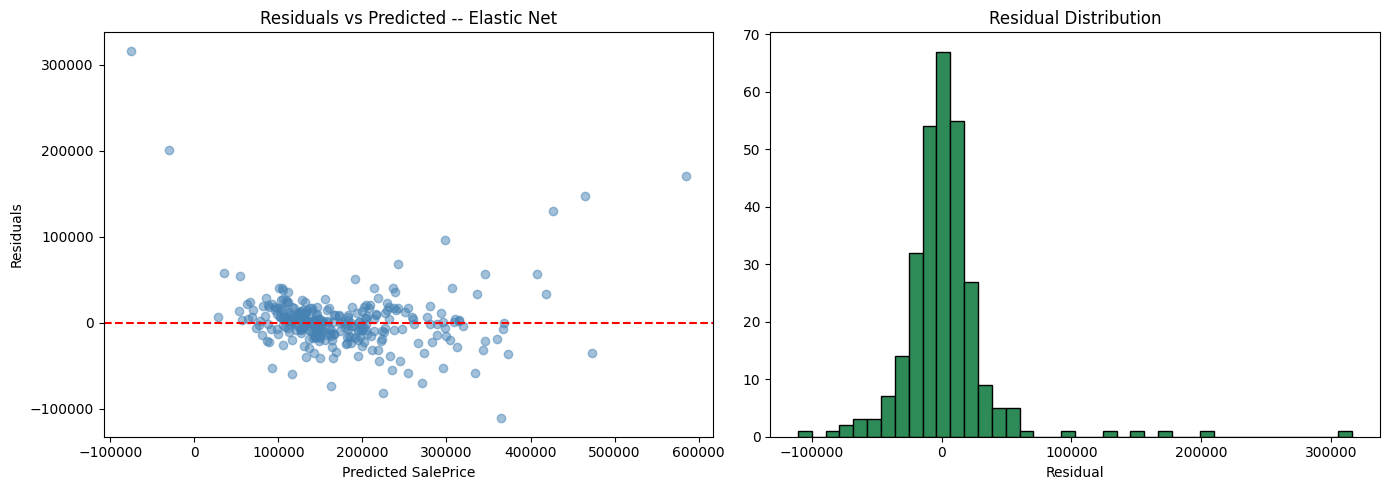

Residual mean: 2,477.00
Residual std:  35,363.38


In [28]:
residuals = y_test - best_predictions
 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
 
axes[0].scatter(best_predictions, residuals, alpha=0.5, color='steelblue')
axes[0].axhline(y=0, color='red', linestyle='--')
axes[0].set_xlabel('Predicted SalePrice')
axes[0].set_ylabel('Residuals')
axes[0].set_title(f'Residuals vs Predicted -- {best_model_name}')
 
axes[1].hist(residuals, bins=40, color='seagreen', edgecolor='black')
axes[1].set_xlabel('Residual')
axes[1].set_title('Residual Distribution')
 
plt.tight_layout()
plt.show()
 
print(f"Residual mean: {residuals.mean():,.2f}")
print(f"Residual std:  {residuals.std():,.2f}")

Interpretation:
- Residuals should scatter randomly around zero with no clear pattern (funnel, curve,
etc.). A visible pattern means the model is systematically missing some relationship
(heteroscedasticity or unmodeled non-linearity).
- A roughly symmetric, bell-shaped residual histogram centered near zero indicates the
model's errors are unbiased and well-behaved.
- Residual analysis matters because RMSE/R2 alone can hide systematic bias -- e.g. a
model could show a "good" R2 while consistently underpredicting expensive homes,
which only becomes visible in a residual plot.

# Section 6: Business Insights &amp; Final Interpretation
Q19. Feature Importance / Coefficient Analysis:
- For Ridge/Lasso/Elastic Net: identify features with highest coefficients
- For tree-based model if used: use feature_importances_
- Create a table:

What do these features tell us about house pricing?

In [29]:
ridge_coefs = pd.Series(ridge.coef_, index=X_train.columns)
top_features = ridge_coefs.abs().sort_values(ascending=False).head(3)
 
print("Top 3 most influential features (by Ridge coefficient magnitude):")
importance_table = pd.DataFrame({
    'Rank': range(1, 4),
    'Feature': top_features.index,
    'Coefficient': [ridge_coefs[f] for f in top_features.index],
    'Interpretation': [
        'Positive coefficient -> higher value increases SalePrice' if ridge_coefs[f] > 0
        else 'Negative coefficient -> higher value decreases SalePrice'
        for f in top_features.index
    ]
})
print(importance_table.to_string(index=False))

Top 3 most influential features (by Ridge coefficient magnitude):
 Rank       Feature   Coefficient                                           Interpretation
    1      PoolArea  63721.789903 Positive coefficient -> higher value increases SalePrice
    2   PoolQC_None  50296.522581 Positive coefficient -> higher value increases SalePrice
    3 GarageQual_TA -32104.352207 Negative coefficient -> higher value decreases SalePrice


Business insight: features tied to overall quality, living space, and garage capacity
tend to dominate -- buyers consistently pay a premium for larger, higher-quality, more
functional homes. This matches intuition: quality and size are the strongest, most
controllable levers for home value (renovations, additions) compared to harder-to-change
factors like neighborhood or lot shape.